In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:


df_clean = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")

print(df_clean.head())
print(df_clean.shape)
print(df_clean.columns)

print(df_clean.info())


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

       Health_Notes  Watering_Amount_ml  Watering_Frequency_days  \
0  Yellowing leaves                 205                        3   
1               NaN                 191                        1   
2    Brittle leaves                 477                        5   
3           New bud                 207                        1   
4           Wilting                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct m

In [18]:
df_clean['Soil_Type'].value_counts()

Soil_Type
Clay      173
Chalky    172
Silty     170
Loamy     166
Peaty     160
Sandy     159
Name: count, dtype: int64

I am importing a seconf time like this bcs i want to keep the clean copy, ik its redundant but ^ its my emotional support copy...

removed negative heights (they confuse me)

In [10]:
df = pd.read_csv('Indoor_Plant_Health_and_Growth_Factors.csv')

df = df[df['Height_cm'] > 0]

i will drop the columns:

'Health_Notes' > i don't think is that relevant, we get to keep the health score. 
'Fertilizer_Type' > doesn't quite impact the water needs of a plant (it's debatable but too time consuming to consider it and kinda negligable when we keep plant height, which is the main thing the fertilizer influences. fertiliser makes plant grow => plant consumes more water. i just cut the "rooot" of it, as the cause-effect doesn't rly matter, just that plant big : plant drinks more)
'Fertilizer_Amount_ml' > very irrelevant
'Pest_Presence' > unless they (pests) drink the soil water (they don't -i think) => irrelevant for our scope
'Pest_Severity' > very irrelevant (but low key debatable, bcs a severe infestation kills the plant which can make it not drink enough, which can make it rot if the model assumes normal water consumption and the plant will not consume it. but i consider that scenario a "nice to have" and out of the scope, we build a watering model not a pest control one. pray our micro farm doesn't get fugnus gnats)

In [ ]:
df = df.drop(columns=['Health_Notes', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity'])

i am mapping the plant ids to categories, to try to keep them but make the system scallable (instead of needing to add a completely new plant species => we add a plant to a category)

i do still feel like these plants do not fit our project (we are doing a plant farm not a deco plants), but oh well : we can add more categories later ig. 

i map them trying to look over biology and phisiology (similar build and needs, which hopefully won't muddy the logic more...)

In [17]:
species_to_category = {
    # Succulents (Like dry soil)
    "Aloe vera": "Succulent",
    "Sansevieria cylindrica": "Succulent",
    "Zamioculcas zamiifolia": "Succulent",
    "Dracaena trifasciata": "Succulent",
    
    # Tropicals (Like moist soil)
    "Monstera deliciosa": "Tropical",
    "Ficus lyrata": "Tropical",
    "Philodendron hederaceum": "Tropical",
    "Spathiphyllum wallisii": "Tropical",
    "Epipremnum aureum": "Tropical",
    "Schefflera arboricola": "Tropical",
    "Aglaonema commutatum": "Tropical",
    "Dieffenbachia seguine": "Tropical",
    "Begonia maculata": "Tropical",
    "Calathea orbifolia": "Tropical",
    "Codiaeum variegatum": "Tropical",
    "Anthurium andraeanum": "Tropical",
    
    # Ferns (Like very moist soil)
    "Nephrolepis exaltata": "Fern",
    
    # Herbaceous (Moderate moisture)
    "Peperomia obtusifolia": "Herbaceous",
    "Chlorophytum comosum": "Herbaceous",
    "Tradescantia zebrina": "Herbaceous"
}

df['Plant_Category'] = df['Plant_ID'].map(species_to_category).fillna('Tropical')


next i simplify the soil. we don't need so many soil types, reasoning:

1. AUK (which is basically a real world impl of our SEP) only has one soil type available. thats so nice to have... they adjust the nutrients and water based on that, and they have multiple plant species.
2. Our users are the type whjo do not want to spend time on soil details, which having different types of soil implies. Easier for them too to only have to choose between soil A or soil B. 
3. For our scope (watering) so many soils are irrelevant. They would be more relevant if we focused on plant health (soil is primary a nutrients source, then the matter of drainage. Nutrients value is irrelevant, off w it. Drainage is very much relevant, bcs if model spits too much water at a plant and soil doesn't allow the roots to breath they can rot. So we split soils in 2 main categories: draining and retentive (horrible word to spell))

In [19]:
soil_to_drainage = {
    "Sandy": "Draining",
    "Chalky": "Draining",
    "Silty": "Retentive",
    "Loamy": "Retentive",
    "Peaty": "Retentive",
    "Clay": "Retentive"
}
df['Soil_Drainage'] = df['Soil_Type'].map(soil_to_drainage)


i map the light for an attempt to simulate real world light fluctuations.

I still use random no, but instead of completely randomly generated no i try to give it a bit of more nmatural approach using standard deviation (idk if its good or nah)

the idea is that using standard random means that the nos will be chaotic in that range, which is artificial noise. I get that it stays in a range that would fit IoT, but if we think finesse - there is no logic behind it while light (wather or artificial) has a curve to it, you don't get 120 LUX (light unit) this second and 186 the next (on avg, i am aware it can happen)

the random normal using deviation is meant to simulate that. we can still get a wider range, and it is still artificial data, but it is (hypothetically) a tad more delicate and more... natural?

idk i hate phisycs and hoped i'd avoid it forever yet here am i calculating light...

In [20]:
light_params = {
    "Low light corner": (100, 30),
    "Filtered sunlight through curtain": (325, 50),
    "Indirect light all day": (475, 60),
    "3h direct morning sun": (725, 70),
    "6h full sun": (911, 80)
}
df['Light'] = df['Sunlight_Exposure'].apply(
    lambda x: np.clip(np.random.normal(*light_params[x]), 0, 1023)
)
df = df.drop('Sunlight_Exposure', axis=1)

In [24]:
num_features = [
    'Height_cm', 'Light', 'Room_Temperature_C', 
    'Humidity_%', 'Soil_Moisture_%', 'Health_Score'
]
cat_features = ['Plant_Category', 'Soil_Drainage']

X_num = df[num_features]
X_cat = df[cat_features]
y = df['Watering_Amount_ml']

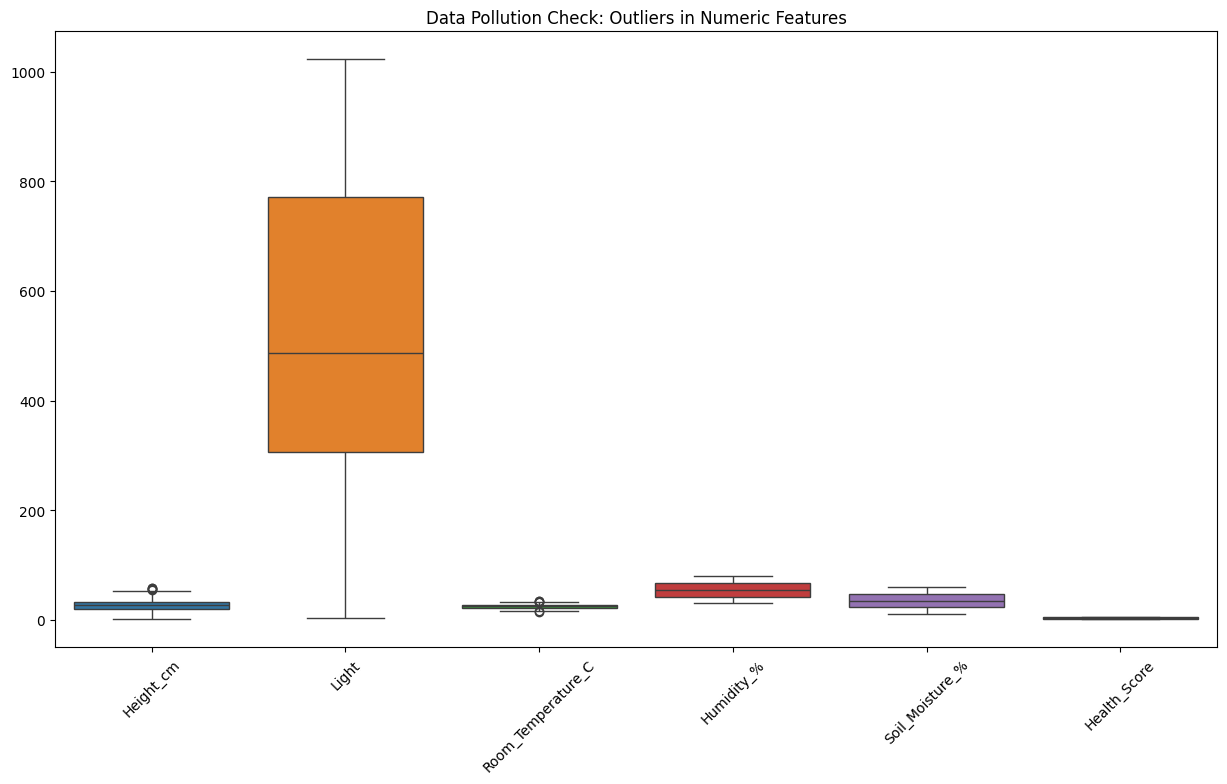

In [25]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_features])
plt.title("Data Pollution Check: Outliers in Numeric Features")
plt.xticks(rotation=45)
plt.show()

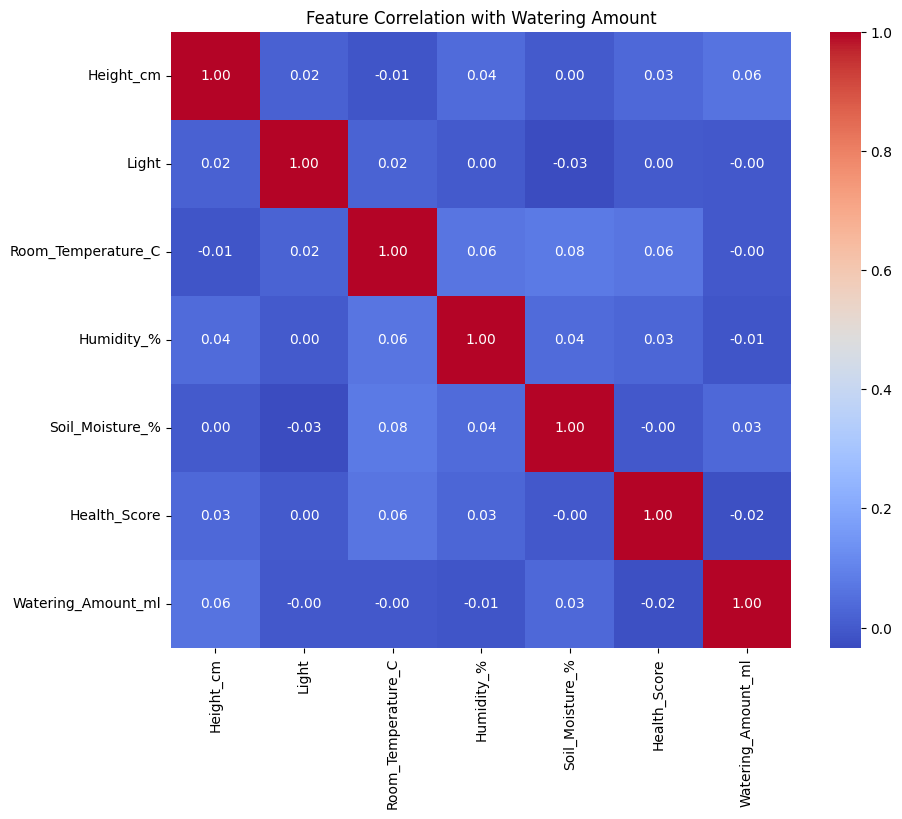

In [26]:
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
corr_matrix = df[num_features + ['Watering_Amount_ml']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Watering Amount")
plt.show()

/tmp/ipykernel_10546/407546804.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Plant_Category', y='Watering_Amount_ml', estimator=np.mean, ci=None)


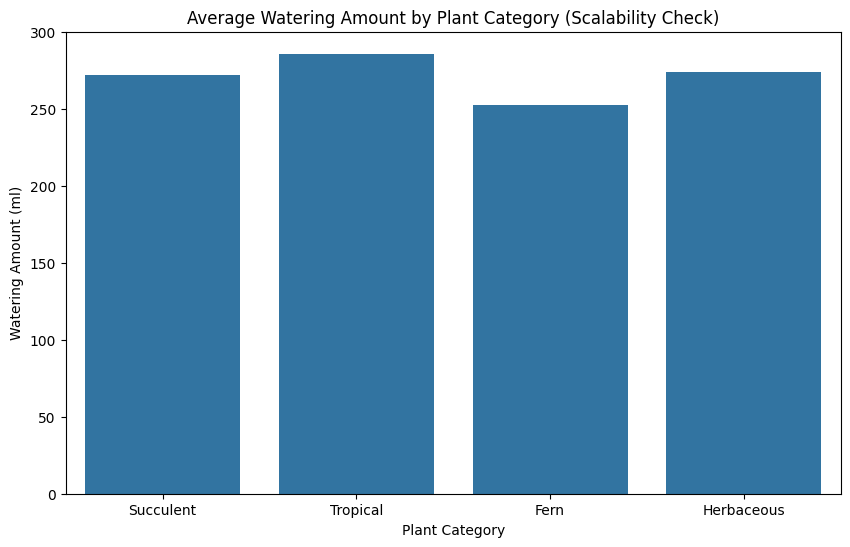

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Plant_Category', y='Watering_Amount_ml', estimator=np.mean, ci=None)
plt.title("Average Watering Amount by Plant Category (Scalability Check)")
plt.ylabel("Watering Amount (ml)")
plt.xlabel("Plant Category")
plt.show()

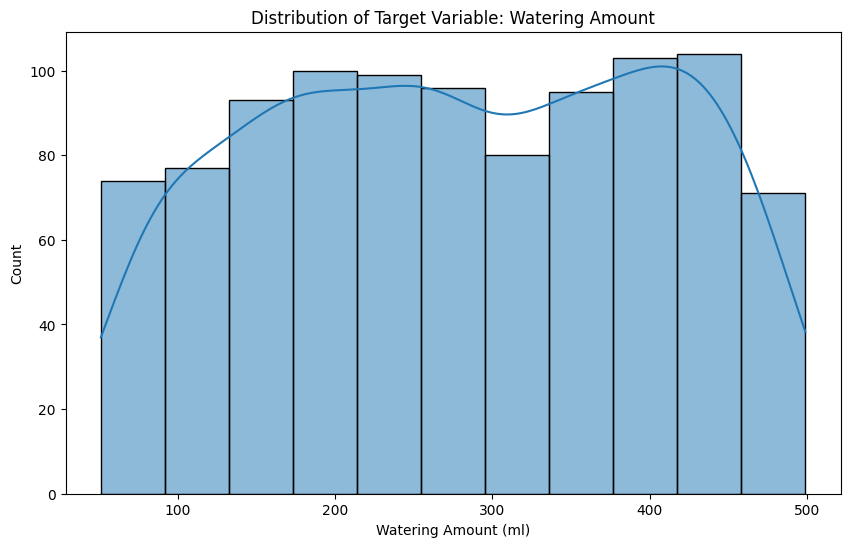

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Watering_Amount_ml'], kde=True)
plt.title("Distribution of Target Variable: Watering Amount")
plt.xlabel("Watering Amount (ml)")
plt.show()